# **CELL 1 — Mount Drive**


In [ ]:
# Connecting to Google drive shared folder.
from google.colab import drive
import os

drive.mount('/content/drive')

FILE_PATH = '/content/drive/MyDrive/Jigsaw_Bias_Project/Datasets/train.csv'

# Handle if somehow train.csv gets deleted.
if os.path.exists(FILE_PATH):
    print("Dataset found.")
else:
    print("train.csv not found!")

Mounted at /content/drive
Dataset found.


# **CELL 2 — Imports + NLP (Setup)**

In [ ]:
# Imports

import pandas as pd
import numpy as np
import re # Regular Expression
import string
import nltk

from nltk.corpus import stopwords # Stopwords Removal
from nltk.stem import WordNetLemmatizer # Word Lemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

# Downloading linguistic resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# **CELL 3 — Text Cleaning Function**

In [ ]:
# CELL 3: TEXT CLEANING FUNCTION

def deep_clean_text(text):
    # If input is not a string (e.g., NaN), return empty string
    if not isinstance(text, str):
        return ""

    # Convert text to lowercase
    text = text.lower()

    # Remove non-ASCII characters (emojis, special symbols, foreign characters)
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # Remove text inside square brackets
    text = re.sub(r'\[.*?\]', '', text)

    # Remove URLs (http/https and www links)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>+', '', text)

    # Remove punctuation
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)

    # Replace newline characters with space
    text = re.sub(r'\n', ' ', text)

    # Remove words containing numbers
    text = re.sub(r'\w*\d\w*', '', text)

    # Tokenize
    words = text.split()

    # Remove stopwords and lemmatize
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back into cleaned string
    return ' '.join(cleaned_words)

# **CELL 4 — Load Data + Prepare Labels**

In [ ]:
train = pd.read_csv(FILE_PATH, nrows=100000)

# Binary toxicity label
train['is_toxic'] = (train['target'] >= 0.5).astype(int) # threshold = 0.5 (range -> 0 to 1)

print("Cleaning text....")
train['clean_text'] = train['comment_text'].apply(deep_clean_text)

# Identity columns for bias audit
identity_columns = [
    'male', 'female',
    'homosexual_gay_or_lesbian',
    'christian', 'muslim',
    'black', 'white'
]

# Convert identity scores to binary
for col in identity_columns:
    train[col] = (train[col] >= 0.5).astype(int)

print("Data ready.")

Cleaning text....
Data ready.


# **CELL 5 — Train/Test Split (Original Data)**

In [ ]:
X = train['clean_text']
y = train['is_toxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Split complete.")

Split complete.


# **CELL 6 — TF-IDF + Logistic Regression Baseline**

In [ ]:
print("Vectorizing text...")
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Training Logistic Regression...")
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_vec, y_train)

print("Predicting...")
y_pred = baseline_model.predict(X_test_vec)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nBaseline Accuracy: {accuracy:.2%}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Vectorizing text...
Training Logistic Regression...
Predicting...

Baseline Accuracy: 94.62%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     18590
           1       0.84      0.30      0.44      1410

    accuracy                           0.95     20000
   macro avg       0.89      0.65      0.70     20000
weighted avg       0.94      0.95      0.93     20000



# **CELL 7 — Confusion Matrix**

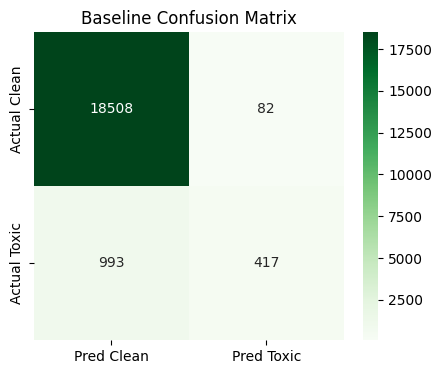

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred Clean','Pred Toxic'],
            yticklabels=['Actual Clean','Actual Toxic'])
plt.title("Baseline Confusion Matrix")
plt.show()

# **CELL 8 — Bias Audit Functions**

In [ ]:
# CELL 8: BIAS METRICS

from sklearn.metrics import confusion_matrix

def compute_fpr_fnr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    return fpr, fnr

def audit_bias(identity):
    test_data = train.loc[X_test.index]

    subgroup = test_data[test_data[identity] == 1]
    background = test_data[test_data[identity] == 0]

    y_true_sub = y_test.loc[subgroup.index]
    y_pred_sub = pd.Series(y_pred, index=y_test.index).loc[subgroup.index]

    y_true_back = y_test.loc[background.index]
    y_pred_back = pd.Series(y_pred, index=y_test.index).loc[background.index]

    fpr_sub, fnr_sub = compute_fpr_fnr(y_true_sub, y_pred_sub)
    fpr_back, fnr_back = compute_fpr_fnr(y_true_back, y_pred_back)

    print(f"\n--- Bias Audit: {identity} ---")
    print(f"Subgroup   → FPR: {fpr_sub:.4f}, FNR: {fnr_sub:.4f}")
    print(f"Background → FPR: {fpr_back:.4f}, FNR: {fnr_back:.4f}")

# **CELL 9 — Run Bias Audit**

In [ ]:
# CELL 9: RUN BIAS CHECK

for identity in identity_columns:
    audit_bias(identity)


--- Bias Audit: male ---
Subgroup   → FPR: 0.0156, FNR: 0.7321
Background → FPR: 0.0042, FNR: 0.7031

--- Bias Audit: female ---
Subgroup   → FPR: 0.0136, FNR: 0.7576
Background → FPR: 0.0042, FNR: 0.7016

--- Bias Audit: homosexual_gay_or_lesbian ---
Subgroup   → FPR: 0.0490, FNR: 0.6875
Background → FPR: 0.0042, FNR: 0.7046

--- Bias Audit: christian ---
Subgroup   → FPR: 0.0282, FNR: 0.7200
Background → FPR: 0.0042, FNR: 0.7040

--- Bias Audit: muslim ---
Subgroup   → FPR: 0.0588, FNR: 0.8276
Background → FPR: 0.0041, FNR: 0.7017

--- Bias Audit: black ---
Subgroup   → FPR: 0.0217, FNR: 0.7714
Background → FPR: 0.0043, FNR: 0.7025

--- Bias Audit: white ---
Subgroup   → FPR: 0.0325, FNR: 0.7708
Background → FPR: 0.0042, FNR: 0.7019


# **CELL 10 — Bias Gap + Severity Classification**

In [ ]:
def classify_gap(gap):
    if gap < 0.02:
        return "Minimal Bias"
    elif 0.02 <= gap <= 0.05:
        return "Moderate Concern"
    else:
        return "Serious Bias Signal"


def audit_bias_gap(identity):
    test_data = train.loc[X_test.index]

    subgroup = test_data[test_data[identity] == 1]
    background = test_data[test_data[identity] == 0]

    y_pred_series = pd.Series(y_pred, index=y_test.index)

    y_true_sub = y_test.loc[subgroup.index]
    y_pred_sub = y_pred_series.loc[subgroup.index]

    y_true_back = y_test.loc[background.index]
    y_pred_back = y_pred_series.loc[background.index]

    fpr_sub, fnr_sub = compute_fpr_fnr(y_true_sub, y_pred_sub)
    fpr_back, fnr_back = compute_fpr_fnr(y_true_back, y_pred_back)

    fpr_gap = abs(fpr_sub - fpr_back)
    fnr_gap = abs(fnr_sub - fnr_back)

    print(f"\n--- {identity.upper()} ---")
    print(f"FPR Gap: {fpr_gap:.4f} → {classify_gap(fpr_gap)}")
    print(f"FNR Gap: {fnr_gap:.4f} → {classify_gap(fnr_gap)}")

# **CELL 11 — Run Full Bias Severity Report**

In [ ]:
for identity in identity_columns:
    audit_bias_gap(identity)


--- MALE ---
FPR Gap: 0.0115 → Minimal Bias
FNR Gap: 0.0290 → Moderate Concern

--- FEMALE ---
FPR Gap: 0.0094 → Minimal Bias
FNR Gap: 0.0559 → Serious Bias Signal

--- HOMOSEXUAL_GAY_OR_LESBIAN ---
FPR Gap: 0.0449 → Moderate Concern
FNR Gap: 0.0171 → Minimal Bias

--- CHRISTIAN ---
FPR Gap: 0.0239 → Moderate Concern
FNR Gap: 0.0160 → Minimal Bias

--- MUSLIM ---
FPR Gap: 0.0547 → Serious Bias Signal
FNR Gap: 0.1259 → Serious Bias Signal

--- BLACK ---
FPR Gap: 0.0174 → Minimal Bias
FNR Gap: 0.0689 → Serious Bias Signal

--- WHITE ---
FPR Gap: 0.0283 → Moderate Concern
FNR Gap: 0.0689 → Serious Bias Signal


# **CELL 12 — Hugging Face Setup & Dataset Tokenization**

In [ ]:
!pip install -q transformers datasets

from transformers import DistilBertTokenizerFast
from datasets import Dataset
import pandas as pd

print("Loading DistilBERT Tokenizer...")
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

print("Converting Pandas DataFrames to Hugging Face Datasets...")
train_df = pd.DataFrame({'text': X_train, 'label': y_train}).reset_index(drop=True)
test_df = pd.DataFrame({'text': X_test, 'label': y_test}).reset_index(drop=True)

hf_train = Dataset.from_pandas(train_df)
hf_test = Dataset.from_pandas(test_df)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding="max_length", truncation=True, max_length=128)

print("Tokenizing the dataset... (This takes about 1-2 minutes)")
tokenized_train = hf_train.map(tokenize_function, batched=True)
tokenized_test = hf_test.map(tokenize_function, batched=True)

print("Data formatted for Deep Learning!")

Loading DistilBERT Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Converting Pandas DataFrames to Hugging Face Datasets...
Tokenizing the dataset... (This takes about 1-2 minutes)


Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Data formatted for Deep Learning!
